<a href="https://colab.research.google.com/github/Fernanda-Martinez/proyecto_final_aprendizaje_automatico/blob/main/proyecto_final_AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Autores:
# Fabián Lasso Rodríguez
# Maria Fernanda Martínez Moreno
# Juan Carlos Majin Narváez
# Diego Cortes Silva
# Kevin Armando Dorado García

In [ ]:
# Importar las librerias
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cargar el dataset desde un archivo local
df = pd.read_csv("student_depression_dataset.csv")

In [ ]:
# Hacer un primer analisis exploratorio de los datos del dataset
df.head()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [ ]:
# Verificar valores nulos por columna
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [ ]:
# Rellenar valores nulos con la media
df["Financial Stress"] = df["Financial Stress"].fillna(df["Financial Stress"].mean())

# Eliminar columnas irrelevantes
df = df.drop("id", axis=1)

In [ ]:
df.isnull().sum()

,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0
Sleep Duration,0


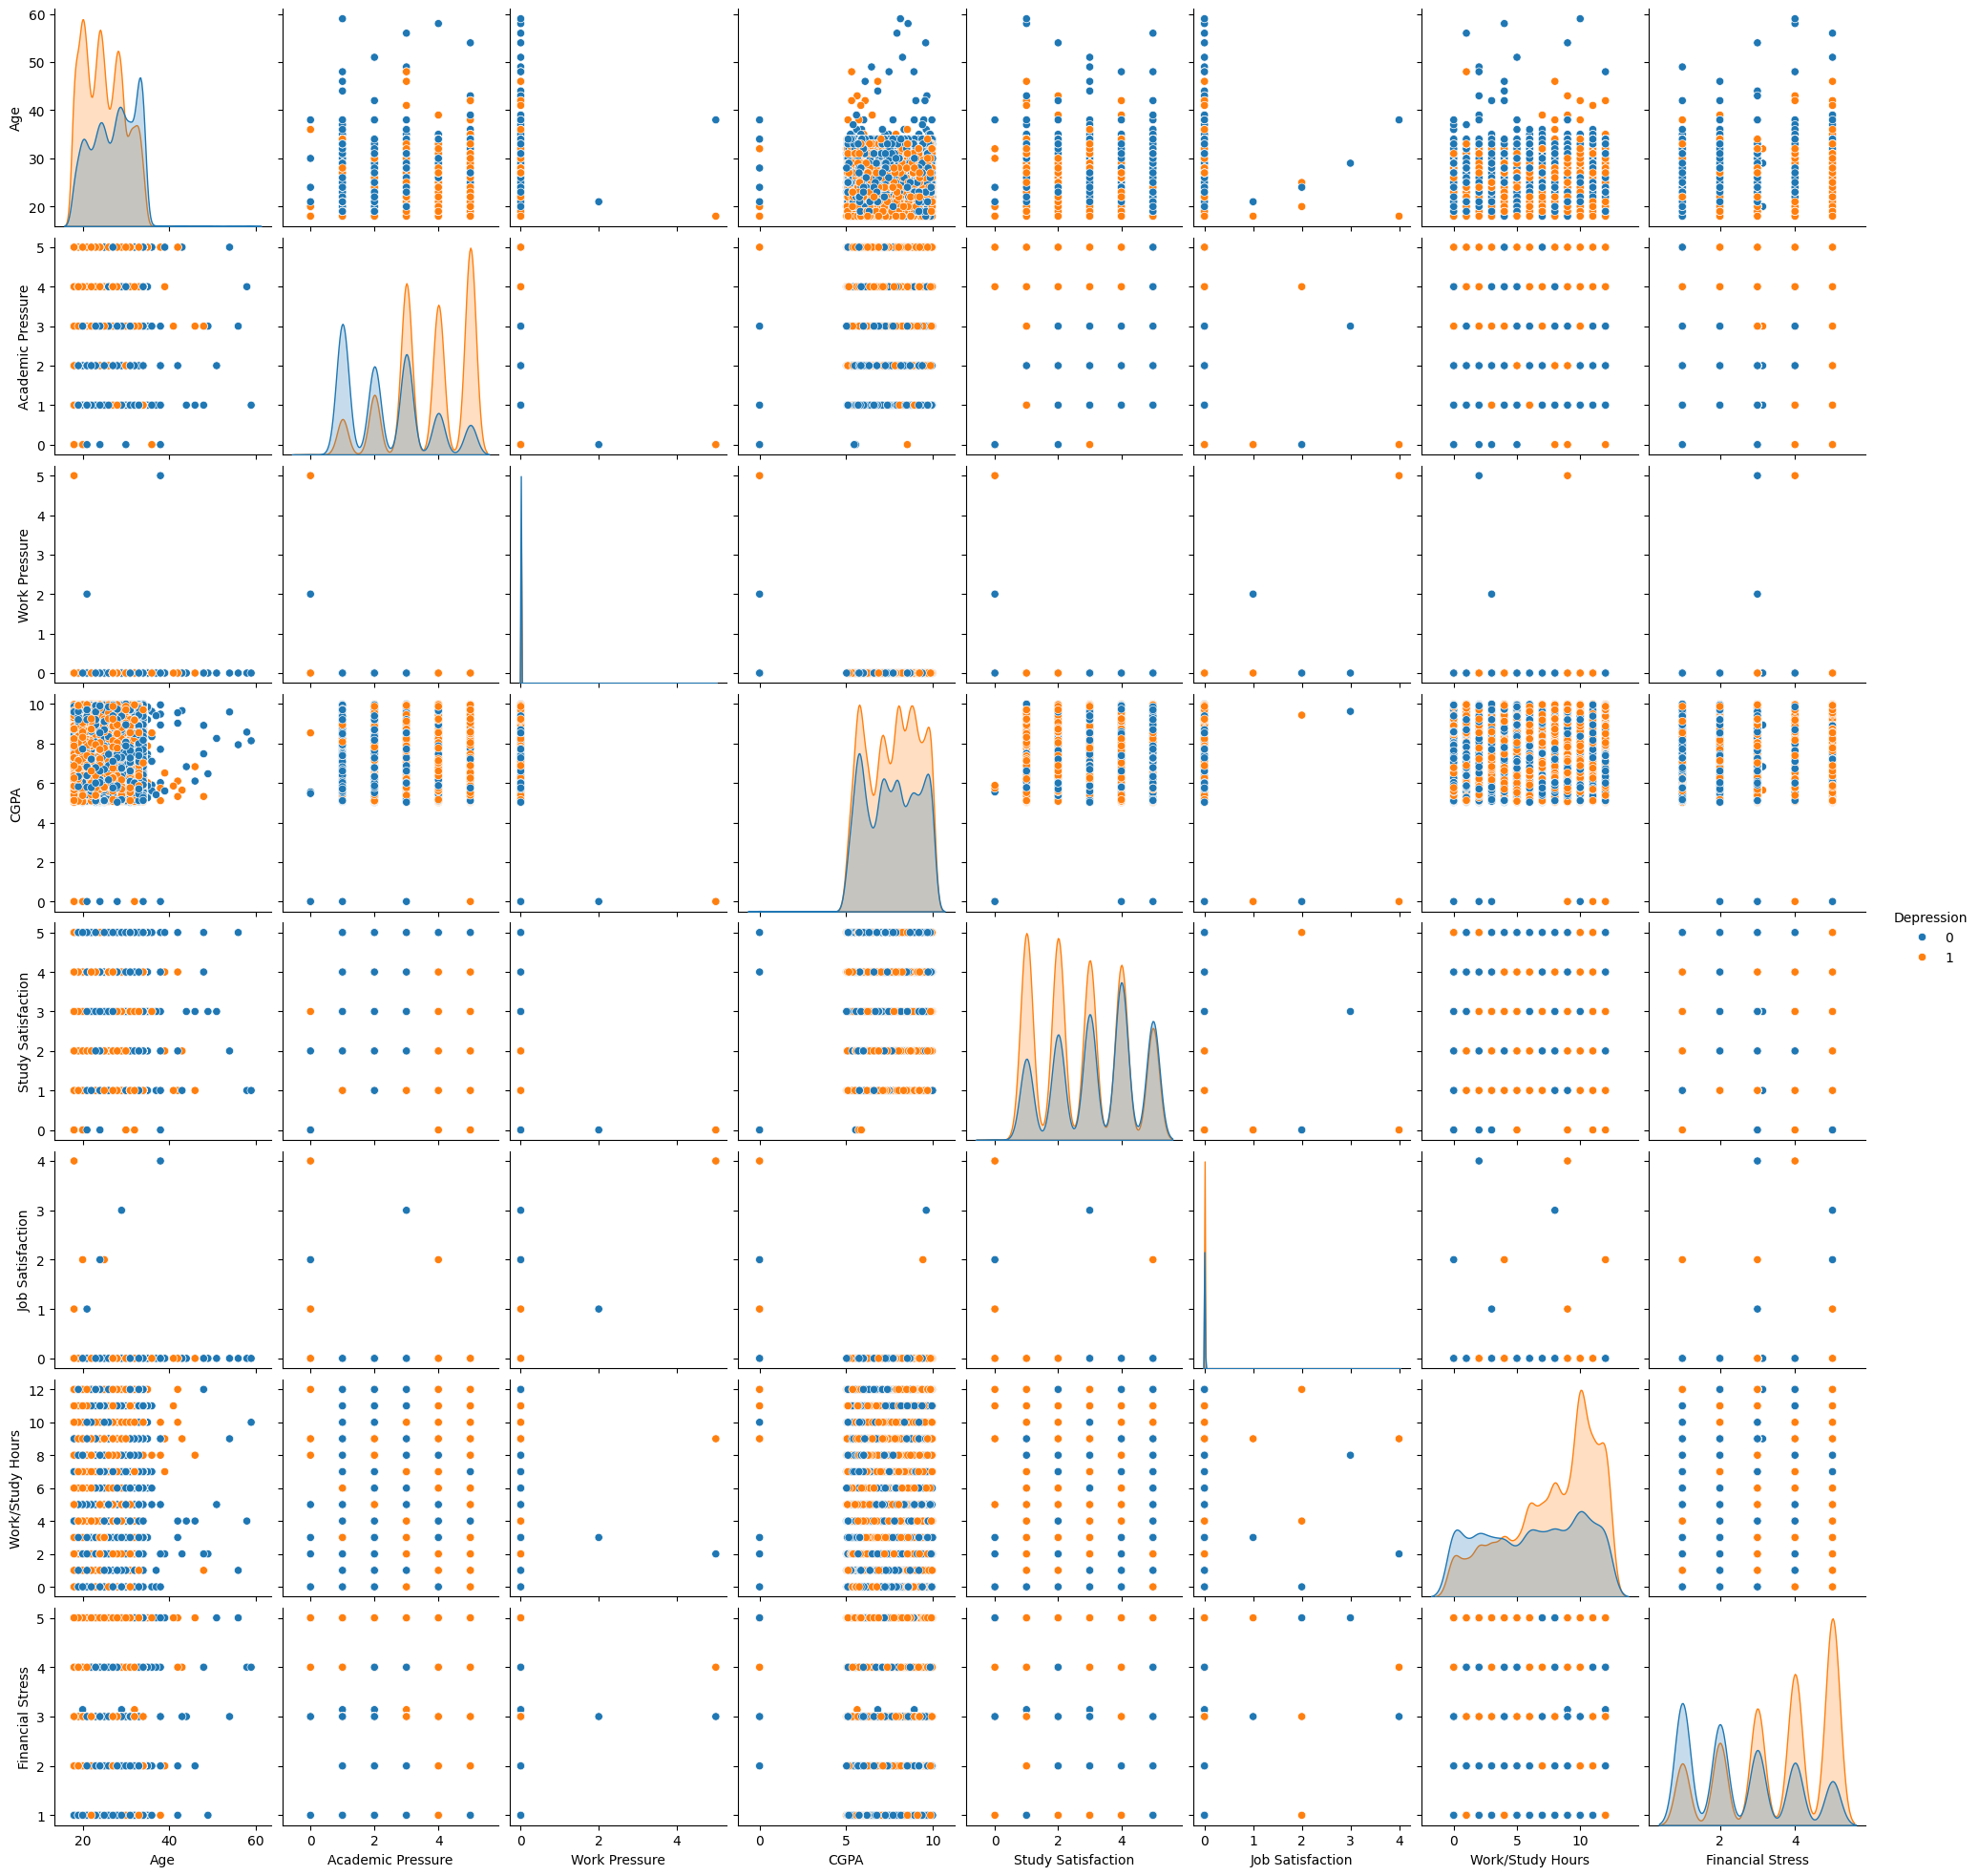

In [ ]:
# Visualizar relaciones entre variables y distribución de clases
sns.pairplot(df, hue='Depression')
plt.show()

El análisis exploratorio mediante el pairplot muestra que la mayoría de las variables son discretas, lo que se refleja en patrones de líneas verticales en las gráficas. Además, se observa una alta superposición entre las clases, lo que indica que no existe una separación clara entre estudiantes con y sin depresión utilizando una sola variable.

In [ ]:
# Contar cantidad de registros por clase (Variable objetivo)
print("Balance del target (Depression):")
print(df['Depression'].value_counts())
print("\nProporción:")
print(df['Depression'].value_counts(normalize=True))

Balance del target (Depression):
Depression
1    16336
0    11565
Name: count, dtype: int64

Proporción:
Depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64


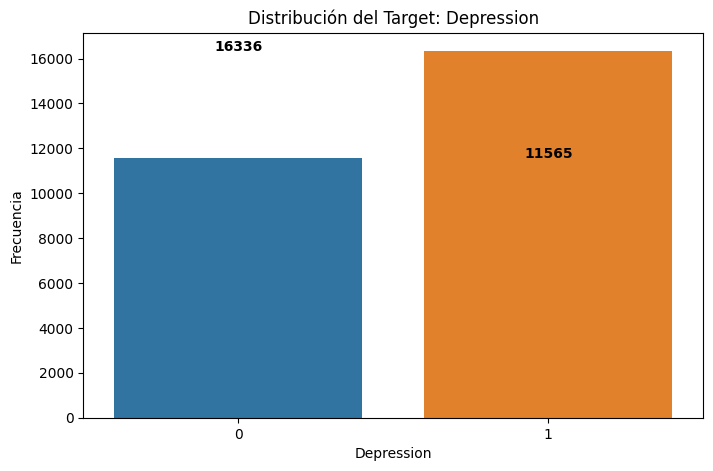

In [ ]:
# Graficar distribución de la variable objetivo
plt.figure(figsize=(8, 5))
sns.countplot(x='Depression', data=df, hue='Depression', legend=False)
plt.title('Distribución del Target: Depression')
plt.xlabel('Depression')
plt.ylabel('Frecuencia')
for i, v in enumerate(df['Depression'].value_counts()):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.show()

La variable objetivo “Depression” presenta aproximadamenteque el 58% de los estudiantes son clasificados con depresión y el 42% sin depresión.

In [ ]:
# Seleccionar columnas numéricas
num_cols = df.select_dtypes(include=np.number).columns

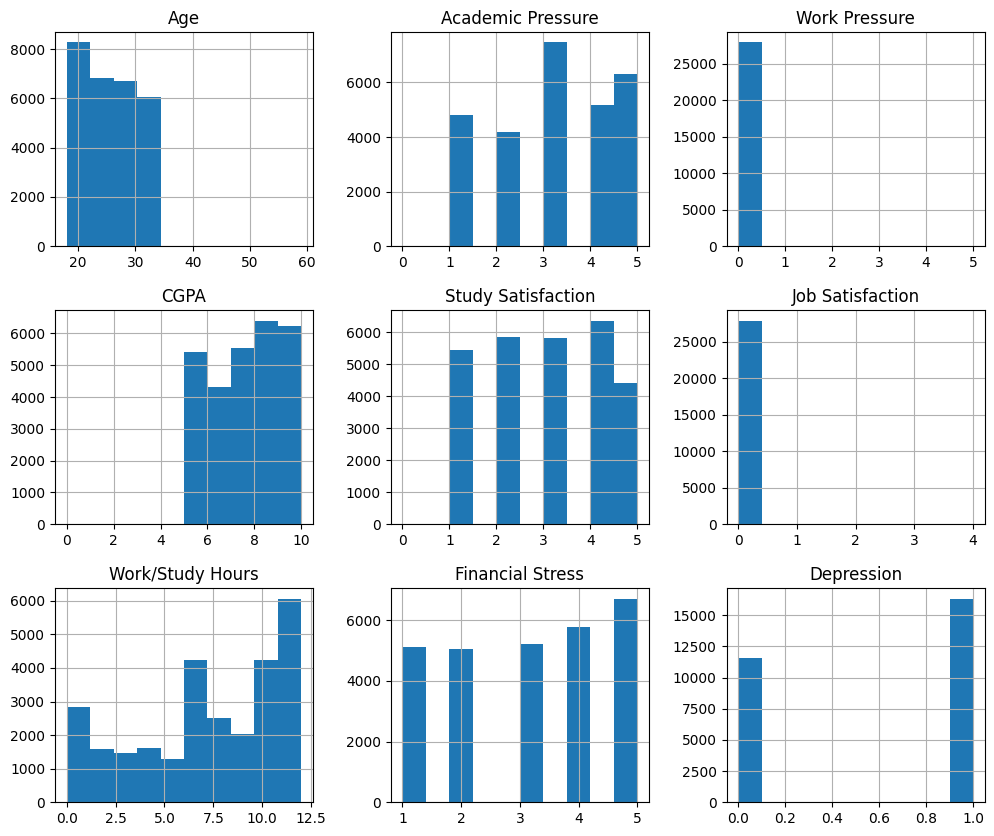

In [ ]:
# Graficar histogramas de variables numéricas
df[num_cols].hist(figsize=(12,10))
plt.show()

El análisis de histogramas muestra que la mayoría de las variables son de tipo discreto, con valores en rangos limitados. Algunas variables como la presión académica, el estrés financiero y las horas de estudio presentan una distribución adecuada para el análisis. Sin embargo, variables como la presión laboral y la satisfacción laboral presentan una alta concentración en valores bajos, lo que podría indicar baja relevancia para el modelo.

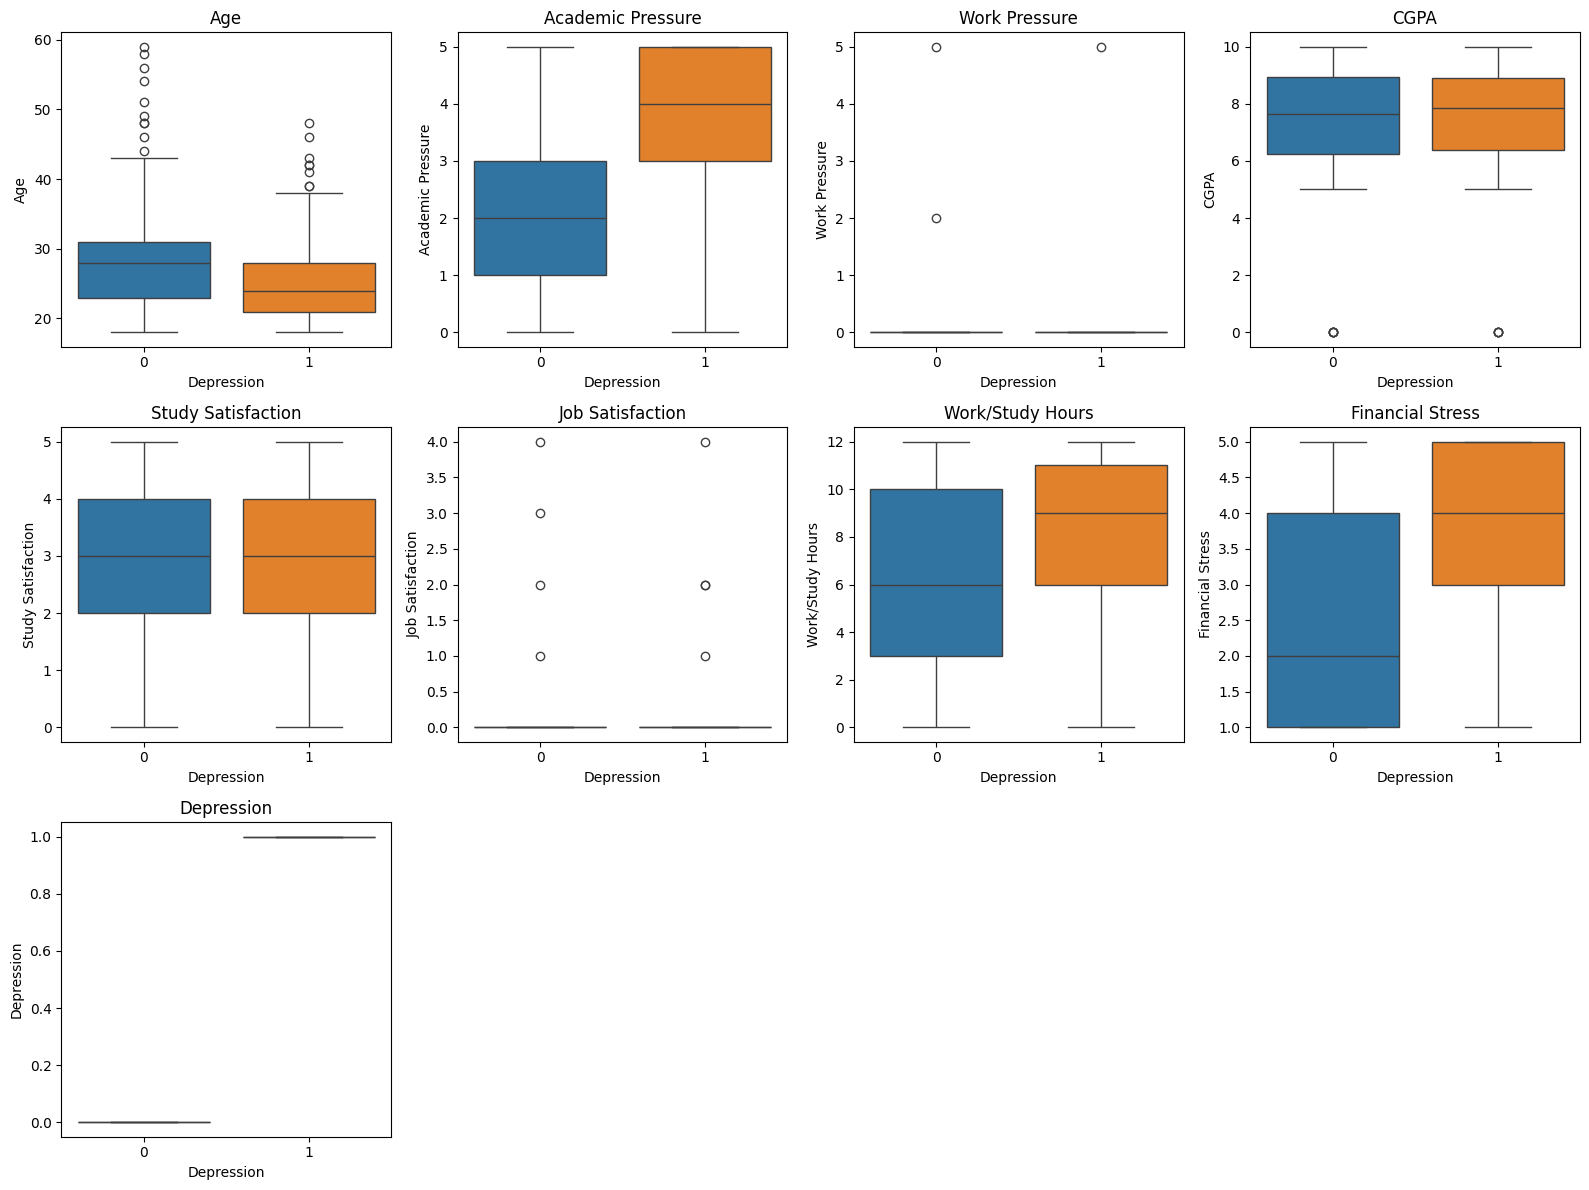

Valores sospechosos (potenciales outliers):
Age: 12 outliers detectados
Work Pressure: 3 outliers detectados
CGPA: 9 outliers detectados
Job Satisfaction: 8 outliers detectados


In [ ]:
# Detectar valores atípicos usando boxplots
# Boxplots por variable numérica
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = len(num_cols)
n_rows = (n_cols + 3) // 4  # Calcula filas necesarias (redondea hacia arriba)

fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Depression', y=col, data=df, ax=axes[i], hue='Depression', legend=False)
    axes[i].set_title(f'{col}')

# Ocultar subplots vacíos
for i in range(n_cols, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

print("Valores sospechosos (potenciales outliers):")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers detectados")

El análisis de valores atípicos muestra que la mayoría de las variables no presentan outliers significativos. Algunos valores extremos observados, especialmente en edad y rendimiento académico, pueden considerarse válidos dentro del contexto del estudio. Variables como presión laboral y satisfacción laboral presentan una alta concentración en valores bajos, lo que indica que pueden tener menor relevancia. En general, no se considera necesario eliminar outliers, ya que no afectan negativamente la calidad del dataset.

In [ ]:
# Seleccionar variables categóricas
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits',
       'Degree', 'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='object')


Gender
Gender
Male      15547
Female    12354
Name: count, dtype: int64


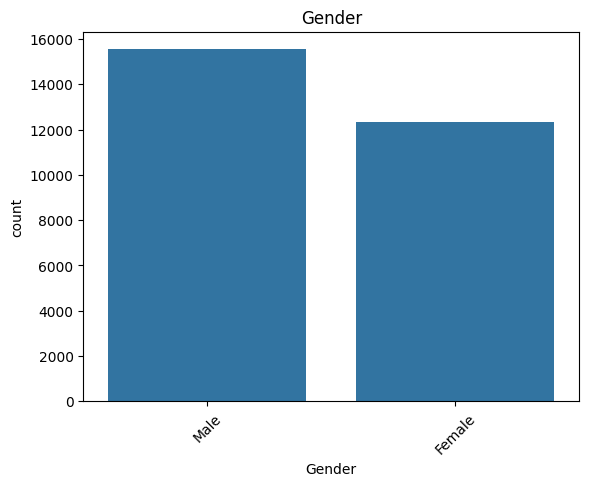


City
City
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad              461
Saanvi                   2
Bhavna                   2
City                     2
Harsha                   2
Less Delhi               1
M.Tech                   1
3.0              

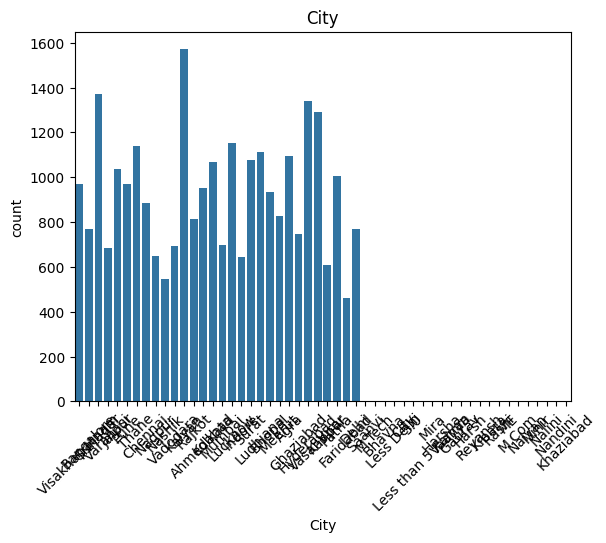


Profession
Profession
Student                   27870
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64


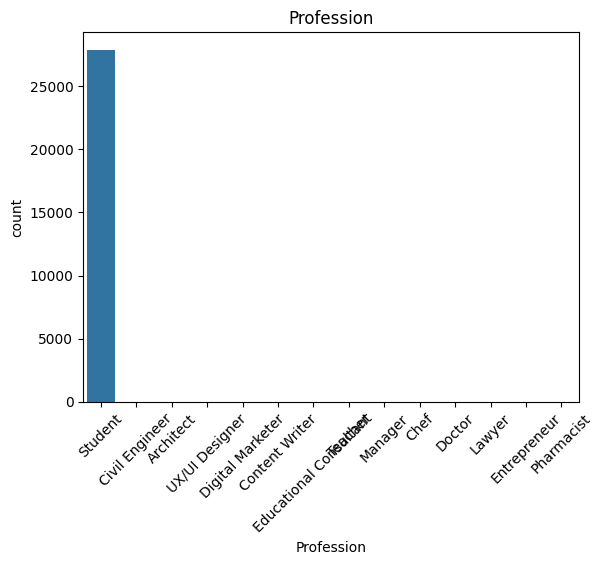


Sleep Duration
Sleep Duration
Less than 5 hours    8310
7-8 hours            7346
5-6 hours            6183
More than 8 hours    6044
Others                 18
Name: count, dtype: int64


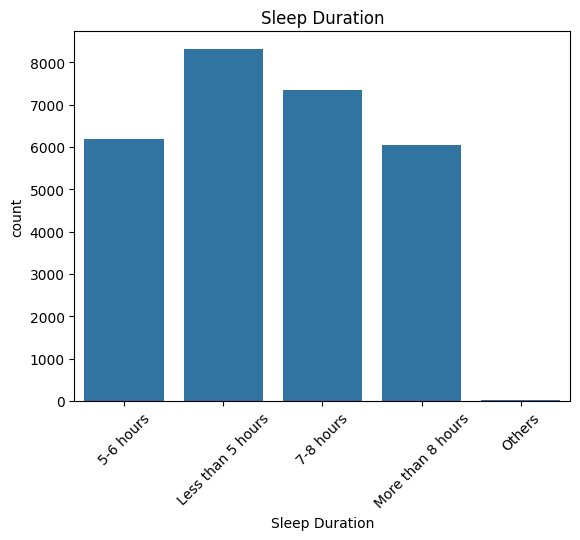


Dietary Habits
Dietary Habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64


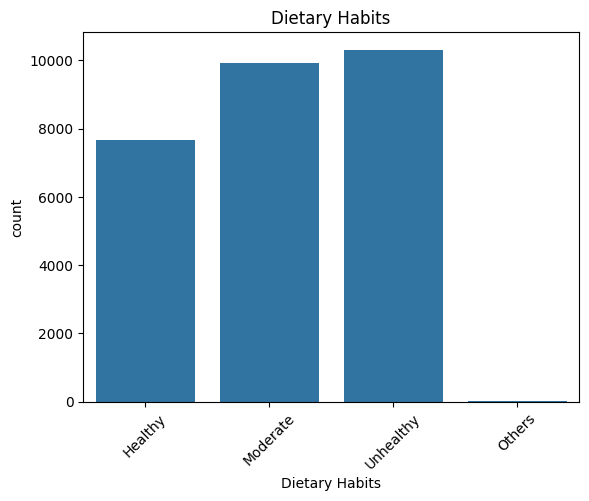


Degree
Degree
Class 12    6080
B.Ed        1867
B.Com       1506
B.Arch      1478
BCA         1433
MSc         1190
B.Tech      1152
MCA         1044
M.Tech      1022
BHM          925
BSc          888
M.Ed         821
B.Pharm      810
M.Com        734
BBA          696
MBBS         696
LLB          671
BE           613
BA           600
M.Pharm      582
MD           572
MBA          562
MA           544
PhD          522
LLM          482
MHM          191
ME           185
Others        35
Name: count, dtype: int64


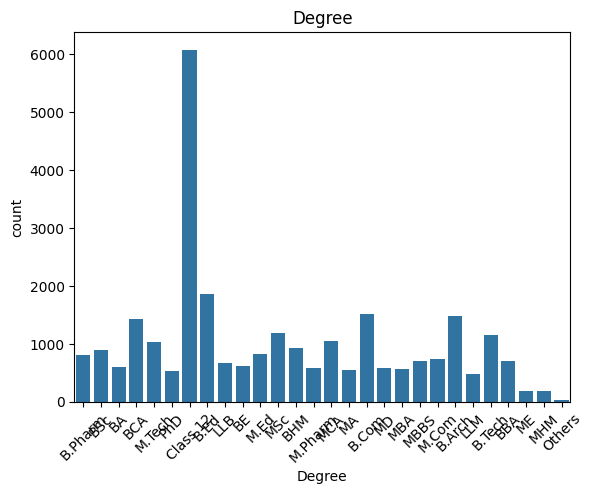


Have you ever had suicidal thoughts ?
Have you ever had suicidal thoughts ?
Yes    17656
No     10245
Name: count, dtype: int64


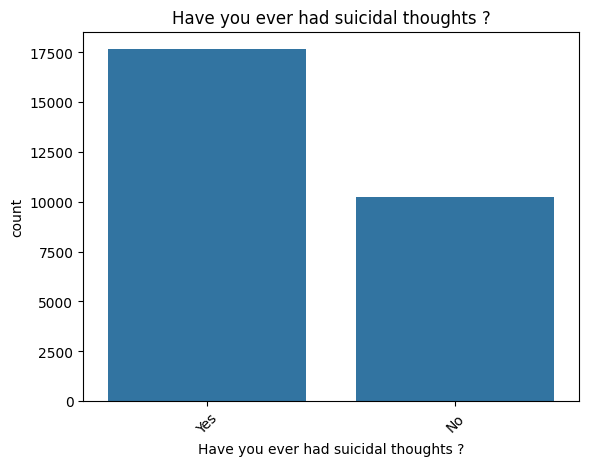


Family History of Mental Illness
Family History of Mental Illness
No     14398
Yes    13503
Name: count, dtype: int64


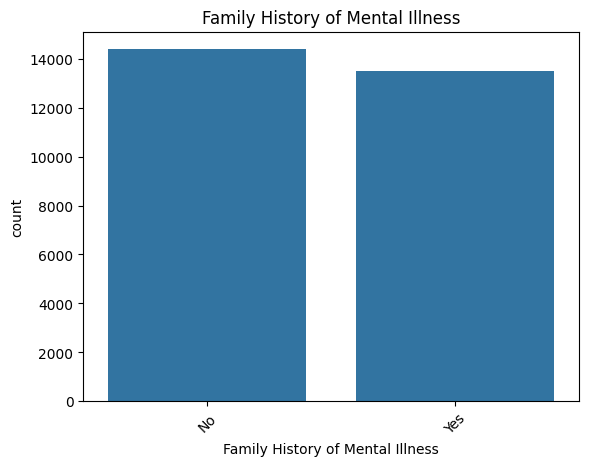

In [ ]:
# Analizar distribución de variables categóricas, con el fin de detectar posibles
# desbalance, calidad de datos, cardinalidad, etc.
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

El análisis de variables categóricas muestra que algunas variables presentan una distribución equilibrada y son potencialmente relevantes para el modelo, como el género, los hábitos alimenticios y la duración del sueño. Variables como pensamientos suicidas y antecedentes familiares de enfermedad mental destacan como factores altamente influyentes. Por otro lado, variables con alta cardinalidad como ciudad y tipo de grado, así como variables con poca variabilidad como profesión, pueden introducir ruido en el modelo, por lo que se considera adecuado eliminarlas.

In [ ]:
# Eliminamos columnas que pueden causar ruidos por tener muchas categorias o ser innecesarias
# Eliminar "City": Más de 30+ ciudades y algunas con muy pocos registros
# Eliminar "Profession": No aporta variabilidad
# Eliminar "Degree": Muchas categorias y algunas con muy pocos registros

df = df.drop(["City", "Profession", "Degree"], axis=1)

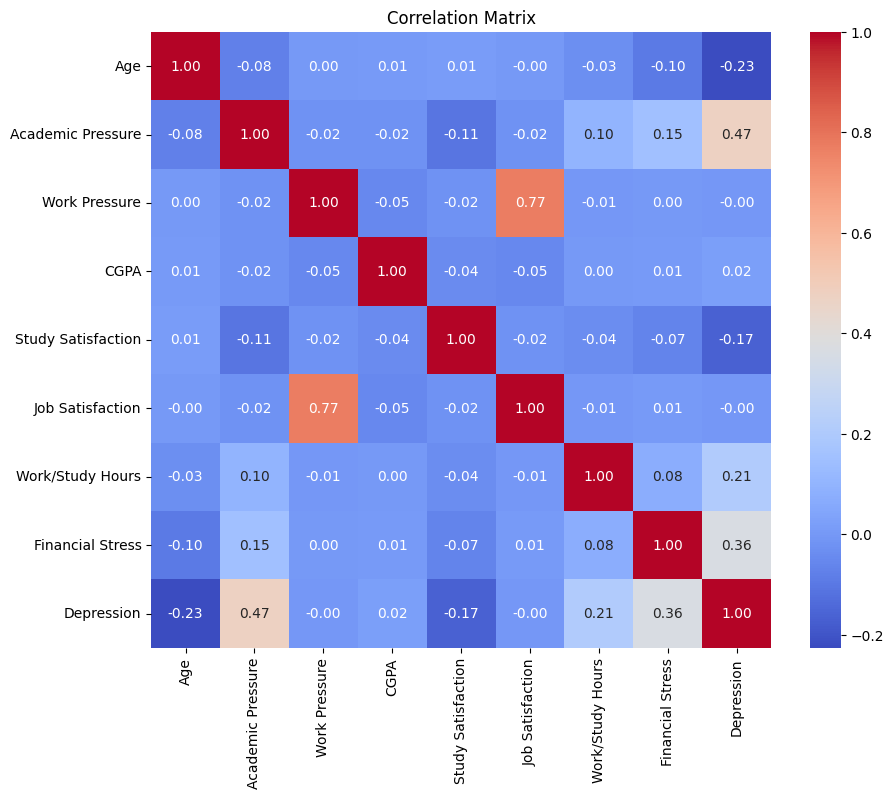

In [ ]:
# Calcular matriz de correlación para variables numéricas
corr = df.corr(numeric_only=True)

# Graficar mapa de calor
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Correlaciones con la variable objetivo:

Positiva

Academic Pressure -> 0.47: A mayor presión académica -> mayor depresión

Financial Stress -> 0.36: A mayor estrés financiero -> mayor depresión

Work/Study Hours -> 0.21: A más carga -> más depresión

Negativa

Study Satisfaction -> -0.17: más satisfacción -> menos depresión

Age -> -0.23: personas más jóvenes -> más depresión (ligero)

No influyen:

CGPA (rendimiento académico) -> 0.02

Irrelevantes:

Work Pressure / Job Satisfaction -> ~0

Pero presentar una correlación ALTA entre ellas -> 0.77

Al ser variables muy parecidas, pueden ser redundantes y generar multicolinealidad por lo que se decide elimina una de las dos


In [ ]:
# Eliminar work pressure.
df = df.drop("Work Pressure", axis=1)

El análisis de correlación muestra que las variables más influyentes en la predicción de la depresión son la presión académica y el estrés financiero, ambas con correlaciones positivas moderadas. Asimismo, la satisfacción con los estudios presenta una relación inversa con la depresión. Variables como el rendimiento académico (CGPA) y la presión laboral no muestran una relación significativa. Además, se identifica una alta correlación entre la presión laboral y la satisfacción laboral, lo que indica redundancia y justifica la eliminación de una de estas variables para evitar problemas de multicolinealidad.

---
# **Preprocesamiento y modelos de Machine Learning**
En esta etapa se implementan las técnicas de preprocesamiento seleccionadas para preparar los datos antes del entrenamiento de los modelos de aprendizaje automático. Las técnicas aplicadas son codificación de variables categóricas (Encoding), escalamiento de características (Feature Scaling) y Análisis de Componentes Principales (PCA) para reducción de dimensionalidad.

Posteriormente, se entrenan y evalúan tres modelos de Machine Learning: Regresión Logística, Random Forest y Support Vector Machine (SVM) con Kernel.

Como primer paso del preprocesamiento, se identifican y separan las variables categóricas y numéricas del conjunto de datos. Esta separación es necesaria porque cada tipo de variable requiere un tratamiento diferente:

Las variables categóricas deben transformarse a formato numérico mediante técnicas de codificación (Encoding).
Las variables numéricas requieren procesos de normalización o estandarización (Feature Scaling) para evitar que las diferencias de escala afecten el desempeño de los modelos.

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

numerical_cols = df.select_dtypes(exclude=["object"]).columns

print("Categorical Variables:")
print(categorical_cols)

print("\nNumerical Variables:")
print(numerical_cols)

Categorical Variables:
Index(['Gender', 'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='object')

Numerical Variables:
Index(['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
       'Job Satisfaction', 'Work/Study Hours', 'Financial Stress',
       'Depression'],
      dtype='object')


Las variables categóricas identificadas en el conjunto de datos fueron transformadas a representaciones numéricas mediante la técnica Label Encoding. Esta transformación es necesaria porque los algoritmos de Machine Learning trabajan con operaciones matemáticas y requieren que todas las variables de entrada se encuentren en formato numérico.

Se utilizó la clase LabelEncoder de la librería Scikit-Learn. Posteriormente, se recorrieron todas las variables categóricas identificadas previamente y se aplicó la función fit_transform(), la cual aprende las categorías existentes y las reemplaza por valores numéricos equivalentes.

# 1. **ENCODING**

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,5.0,8.97,2.0,0.0,0,0,1,3.0,1.0,0,1
1,0,24.0,2.0,5.90,5.0,0.0,0,1,0,3.0,2.0,1,0
2,1,31.0,3.0,7.03,5.0,0.0,2,0,0,9.0,1.0,1,0
3,0,28.0,3.0,5.59,2.0,0.0,1,1,1,4.0,5.0,1,1
4,0,25.0,4.0,8.13,3.0,0.0,0,1,1,1.0,1.0,0,0


In [ ]:
# Verificamos que todo quede numérico
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  int64  
 1   Age                                    27901 non-null  float64
 2   Academic Pressure                      27901 non-null  float64
 3   CGPA                                   27901 non-null  float64
 4   Study Satisfaction                     27901 non-null  float64
 5   Job Satisfaction                       27901 non-null  float64
 6   Sleep Duration                         27901 non-null  int64  
 7   Dietary Habits                         27901 non-null  int64  
 8   Have you ever had suicidal thoughts ?  27901 non-null  int64  
 9   Work/Study Hours                       27901 non-null  float64
 10  Financial Stress                       27901 non-null  float64
 11  Fa

# **2. FEATURE SCALING**

Una vez transformadas las variables categóricas a formato numérico, se aplicó un proceso de escalamiento de características (Feature Scaling) mediante la técnica StandardScaler.

El objetivo de este procedimiento es normalizar la escala de las variables predictoras, evitando que aquellas con valores numéricos más grandes tengan una influencia desproporcionada sobre el proceso de aprendizaje de los modelos.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Primero separamos X y Y
X = df.drop("Depression", axis=1)
y = df["Depression"]

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Escalado
scaler = StandardScaler()

# Ajustar el scaler únicamente con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la misma transformación al conjunto de prueba
X_test_scaled = scaler.transform(X_test)

# Validación
print("Train Shape:", X_train_scaled.shape)
print("Test Shape:", X_test_scaled.shape)

Train Shape: (22320, 12)
Test Shape: (5581, 12)


En primer lugar, se separó la variable objetivo denominada Depression de las variables predictoras. Posteriormente, el conjunto de datos se dividió en un subconjunto de entrenamiento (80%) y un subconjunto de prueba (20%).

Una vez realizada la partición, se aplicó la técnica de estandarización mediante StandardScaler, ajustando el escalador únicamente con los datos de entrenamiento y aplicando posteriormente la misma transformación al conjunto de prueba. Este procedimiento evita fugas de información (data leakage) y garantiza una evaluación más realista del desempeño de los modelos de Machine Learning.

Como resultado, las variables fueron transformadas a una escala con media cercana a 0 y desviación estándar cercana a 1, favoreciendo el rendimiento de algoritmos sensibles a las diferencias de magnitud entre características.

# **3. PCA**

El Análisis de Componentes Principales (PCA, Principal Component Analysis) es una técnica de reducción de dimensionalidad que transforma las variables originales en un nuevo conjunto de variables denominadas componentes principales.

Estas componentes son combinaciones lineales de las variables originales y están ordenadas de acuerdo con la cantidad de variabilidad de los datos que logran explicar.

En este proyecto, PCA se emplea con fines exploratorios y de visualización para analizar la distribución de las observaciones en un espacio bidimensional.

In [ ]:
from sklearn.decomposition import PCA

# PCA a 2 componentes para visualización
pca = PCA(n_components=2)

# Ajustar PCA solo con entrenamiento
X_train_pca = pca.fit_transform(X_train_scaled)

# Aplicar misma transformación a prueba
X_test_pca = pca.transform(X_test_scaled)

# Varianza explicada
print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

# Varianza acumulada
print("Varianza total explicada:")
print(sum(pca.explained_variance_ratio_))

Varianza explicada por componente:
[0.13619711 0.08959563]
Varianza total explicada:
0.22579273391873078


El primer componente principal (PC1) explica aproximadamente el 13.62% de la variabilidad total de los datos, mientras que el segundo componente principal (PC2) explica cerca del 8.96%.

En conjunto, ambos componentes conservan aproximadamente el 22.58% de la información presente en el conjunto de datos original.

 Esto evidencia que el problema de predicción de depresión estudiantil presenta una estructura multidimensional donde múltiples variables contribuyen a la información relevante.

In [ ]:
pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"]
)

pca_df["Depression"] = y_train.values

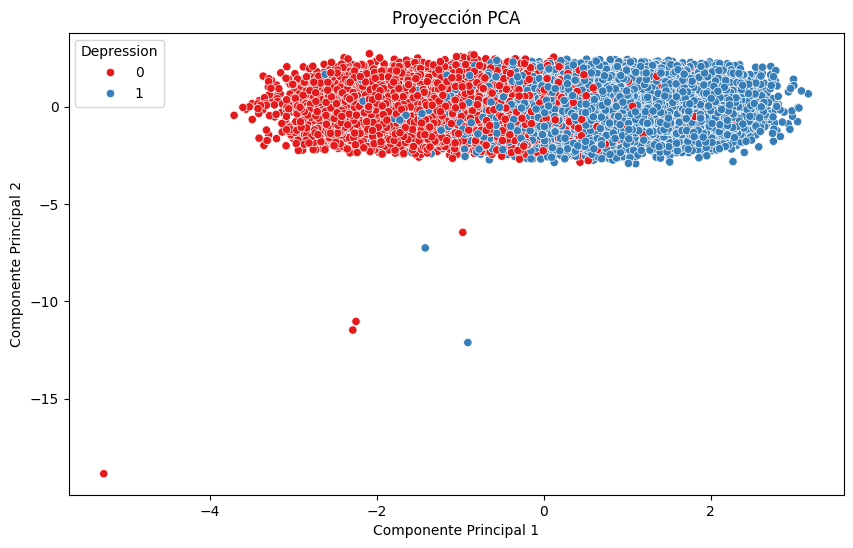

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Depression",
    palette="Set1"
)

plt.title("Proyección PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

La proyección de los datos sobre los dos primeros componentes principales muestra una diferenciación parcial entre las clases asociadas a la variable objetivo Depression.

Se observa que los registros correspondientes a estudiantes sin depresión (0) y con depresión (1) tienden a concentrarse en regiones diferentes del primer componente principal (PC1). En general, los casos con depresión presentan una mayor concentración hacia los valores negativos de PC1, mientras que los casos sin depresión se distribuyen principalmente hacia los valores positivos.

Sin embargo, también se aprecia una zona considerable de superposición entre ambas clases, especialmente alrededor del centro de la distribución. Esto indica que los dos primeros componentes principales no son suficientes para separar completamente los grupos y que la clasificación depende de relaciones más complejas presentes en dimensiones adicionales del conjunto de datos.

In [ ]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

print(varianza_acumulada)

[0.13619711 0.22579273 0.31344595 0.39871439 0.48213836 0.56467366
 0.64443908 0.72207673 0.79743654 0.87045368 0.94010866 1.        ]


Para conservar aproximadamente el 80% de la información original del conjunto de datos serían necesarios 9 componentes principales. Asimismo, para preservar cerca del 90% de la variabilidad total se requerirían 11 componentes. Esto confirma que la información relevante se encuentra distribuida en múltiples variables y que una reducción a únicamente dos componentes implica una pérdida considerable de información.

Sin embargo, esta reducción sigue siendo útil para fines exploratorios y de visualización, permitiendo identificar patrones generales, agrupamientos o posibles tendencias entre las observaciones.

# **DATASET FINAL**

In [ ]:
# Dataset final para los modelos

X_train_final = X_train_scaled
X_test_final = X_test_scaled

print("Entrenamiento:", X_train_final.shape)
print("Prueba:", X_test_final.shape)

Entrenamiento: (22320, 12)
Prueba: (5581, 12)


Una vez completadas las etapas de codificación, partición de datos y escalamiento, se obtuvo el conjunto de datos final que será utilizado para el entrenamiento y evaluación de los modelos de Machine Learning.

El conjunto de entrenamiento contiene el 80% de las observaciones y se empleará para ajustar los modelos predictivos, mientras que el conjunto de prueba contiene el 20% restante y permitirá evaluar la capacidad de generalización de los algoritmos sobre datos no observados previamente.

Durante la partición se utilizó el parámetro stratify=y, garantizando que la proporción de las clases de la variable objetivo se mantuviera consistente en ambos subconjuntos.

# **Modelos**

Con el conjunto de datos preprocesado se procedió a la selección de tres algoritmos de clasificación supervisada para la predicción de la variable objetivo Depression.

Los modelos seleccionados fueron:

Regresión Logística, utilizada como modelo lineal de referencia para problemas de clasificación binaria.
Random Forest, basado en un conjunto de árboles de decisión que permite capturar relaciones no lineales entre las variables.
Support Vector Machine (SVM) con Kernel, capaz de construir fronteras de decisión complejas y de alto poder predictivo en problemas de clasificación.

# **Métricas de evaluación**

Para evaluar el desempeño de los modelos se emplearon diferentes métricas de clasificación:

Accuracy: proporción total de predicciones correctas.
Precision: capacidad del modelo para minimizar falsos positivos.
Recall (Sensibilidad): capacidad para identificar correctamente los casos positivos.
F1-Score: media armónica entre precisión y recall.

# **Estrategia de validación**

Con el fin de obtener estimaciones más robustas del desempeño de los modelos, se utilizó validación cruzada estratificada mediante StratifiedKFold.

Este método conserva la proporción original de las clases en cada partición, reduciendo el riesgo de obtener evaluaciones sesgadas debido a distribuciones desbalanceadas.

Adicionalmente, se empleó GridSearchCV para realizar la búsqueda sistemática de hiperparámetros óptimos, permitiendo mejorar el rendimiento de los modelos evaluado

In [ ]:
# MODELOS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# MÉTRICAS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# VALIDACIÓN
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# PIPELINES
from sklearn.pipeline import Pipeline

# **1. LOGISTIC REGRESSION**

In [ ]:
# LOGISTIC REGRESSION

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Entrenamiento
lr_model.fit(X_train_final, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# prediccion
y_pred_lr = lr_model.predict(X_test_final)

In [ ]:
# metricas
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.842501343845189
Precision: 0.8551888195063931
Recall: 0.8800489596083231
F1-Score: 0.8674408083245363


Los resultados obtenidos muestran sobre el modelo de Regresión Logística.

La exactitud (Accuracy) alcanzó un valor de 84.25%, indicando que aproximadamente ocho de cada diez observaciones fueron clasificadas correctamente.

La precisión (Precision) fue de 85.52%, lo que significa que la mayoría de los estudiantes identificados por el modelo como casos de depresión efectivamente pertenecían a dicha categoría.

Por su parte, el Recall obtuvo un valor de 88.00%, evidenciando una alta capacidad para detectar correctamente los casos positivos presentes en el conjunto de prueba.

Finalmente, el F1-Score alcanzó 86.74%, reflejando un adecuado equilibrio entre precisión y sensibilidad.

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



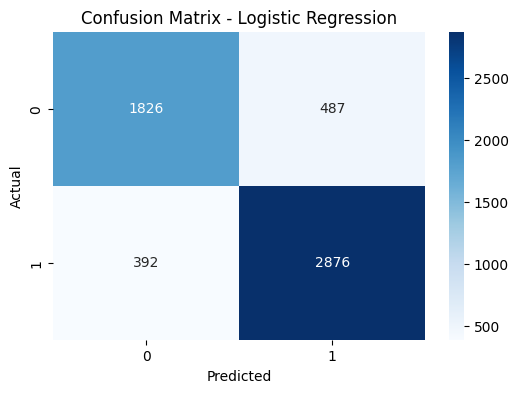

In [ ]:
# Reporte de clasificacion
print(classification_report(y_test, y_pred_lr))

# matriz de confusion
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Para los estudiantes clasificados como no depresivos (clase 0), el modelo alcanzó una precisión del 82% y un recall del 79%. Esto indica que la mayoría de las predicciones realizadas para esta clase fueron correctas, aunque algunos estudiantes sin depresión fueron clasificados erróneamente como casos positivos.

Para la clase correspondiente a estudiantes con depresión (clase 1), el modelo obtuvo una precisión del 86% y un recall del 88%. Estos resultados muestran una alta capacidad para identificar correctamente los casos positivos, aspecto especialmente importante debido al objetivo del proyecto de detectar posibles situaciones de riesgo asociadas a la salud mental.

**Verdaderos Negativos (TN)**
El modelo clasificó correctamente 1826 estudiantes que realmente no presentaban depresión.

**Falsos Positivos (FP)**
487 estudiantes fueron clasificados como casos de depresión cuando en realidad pertenecían a la clase sin depresión.

**Falsos Negativos (FN)**
392 estudiantes con depresión no fueron identificados correctamente por el modelo y fueron clasificados como no depresivos.

**Verdaderos Positivos (TP)**
El modelo identificó correctamente 2876 estudiantes que efectivamente presentaban depresión.

Desde la perspectiva del problema estudiado, los falsos negativos representan estudiantes con posibles síntomas de depresión que no fueron detectados por el modelo. Debido a las implicaciones asociadas a este tipo de error, resulta especialmente relevante el valor de recall obtenido (88%), ya que evidencia una elevada capacidad para identificar correctamente los casos positivos.

# **Conclusion de regresión logística**

La Regresión Logística obtuvo un desempeño satisfactorio en la clasificación de estudiantes con y sin depresión, alcanzando una exactitud del 84.25% y un F1-Score de 86.74%.

El análisis de la matriz de confusión evidenció que el modelo clasificó correctamente 2876 estudiantes con depresión y 1826 estudiantes sin depresión.

Adicionalmente, el recall del 88% demuestra una alta capacidad para detectar casos positivos, característica especialmente relevante en aplicaciones relacionadas con salud mental, donde la omisión de casos reales puede tener consecuencias significativas.

En general, los resultados obtenidos indican que la Regresión Logística constituye una línea base sólida para el problema de clasificación planteado y permite validar la existencia de relaciones significativas entre las variables predictoras y la presencia de depresión estudiantil.

# **2. SVM**


In [ ]:
# SVM

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

# Entrenamiento
svm_model.fit(X_train_final, y_train)

SVC(probability=True, random_state=42)

In [ ]:
# prediccion
y_pred_svm = svm_model.predict(X_test_final)

# metricas
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-Score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.8423221644866511
Precision: 0.8503521126760564
Recall: 0.8867809057527539
F1-Score: 0.8681845416417017


El modelo SVM alcanzó una exactitud del 84.23%, un valor muy similar al obtenido por la Regresión Logística.

La precisión fue del 85.04%, indicando que la mayoría de los estudiantes clasificados como casos de depresión efectivamente pertenecían a dicha categoría.

El recall alcanzó un valor de 88.68%, convirtiéndose en la métrica más destacada del modelo. Este resultado evidencia una elevada capacidad para detectar estudiantes con depresión, aspecto especialmente relevante considerando el contexto del problema.

Finalmente, el F1-Score obtuvo un valor de 86.82%, reflejando un equilibrio adecuado entre precisión y sensibilidad.

              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2313
           1       0.85      0.89      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



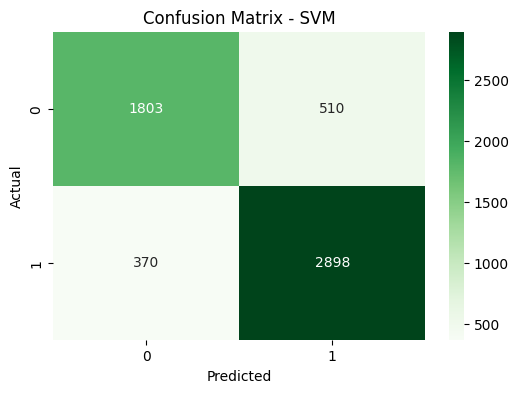

In [ ]:
# Reporte de clasificacion
print(classification_report(y_test, y_pred_svm))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Para los estudiantes sin depresión (clase 0), el modelo alcanzó una precisión del 83% y un recall del 78%. Esto indica que la mayoría de los casos negativos fueron correctamente identificados, aunque existe cierta dificultad para separar completamente ambas clases.

Para la clase correspondiente a estudiantes con depresión, el modelo obtuvo una precisión del 85% y un recall del 89%, evidenciando una alta capacidad para identificar correctamente los casos positivos presentes en el conjunto de prueba.

**Verdaderos Negativos (TN)**
El modelo clasificó correctamente 1803 estudiantes que no presentaban depresión.

**Falsos Positivos (FP)**
510 estudiantes fueron clasificados como depresivos cuando en realidad pertenecían a la clase negativa.

**Falsos Negativos (FN)**
370 estudiantes con depresión no fueron detectados correctamente por el modelo.

**Verdaderos Positivos (TP)**
El modelo identificó correctamente 2898 estudiantes con depresión.

Comparado con la Regresión Logística, el modelo SVM logró reducir el número de falsos negativos de 392 a 370 casos. Esto implica una mejor capacidad para detectar estudiantes con depresión, aspecto especialmente importante debido al impacto que puede tener la omisión de casos positivos en aplicaciones relacionadas con salud mental.

# **Conclusion de SVM**

El modelo Support Vector Machine presentó un desempeño sobresaliente en la clasificación de estudiantes con y sin depresión. Aunque la exactitud global fue similar a la obtenida por la Regresión Logística, SVM alcanzó los mejores valores de recall y F1-Score entre los modelos evaluados hasta el momento.

La matriz de confusión mostró que el modelo fue capaz de identificar correctamente 2898 estudiantes con depresión y reducir el número de falsos negativos respecto a la Regresión Logística. Estos resultados sugieren que SVM constituye una alternativa robusta para la detección temprana de estudiantes con riesgo de depresión.

# **3. RANDOM FOREST**

In [ ]:
# RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamiento
rf_model.fit(X_train_final, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predicción
y_pred_rf = rf_model.predict(X_test_final)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8392761153915069
Precision: 0.8527224040464148
Recall: 0.8769889840881273
F1-Score: 0.8646854729220094


El modelo Random Forest alcanzó una exactitud del 83.93%.

La precisión obtenida fue del 85.27%, evidenciando que la mayoría de los estudiantes identificados por el modelo como casos de depresión realmente pertenecían a dicha categoría.

El recall alcanzó un valor de 87.70%, demostrando una buena capacidad para detectar estudiantes con depresión. Sin embargo, este valor es ligeramente inferior al obtenido por la Regresión Logística y SVM.

El F1-Score fue de 86.47%, reflejando un equilibrio adecuado entre precisión y sensibilidad. No obstante, este resultado es ligeramente inferior al obtenido por los otros modelos evaluados.

              precision    recall  f1-score   support

           0       0.82      0.79      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



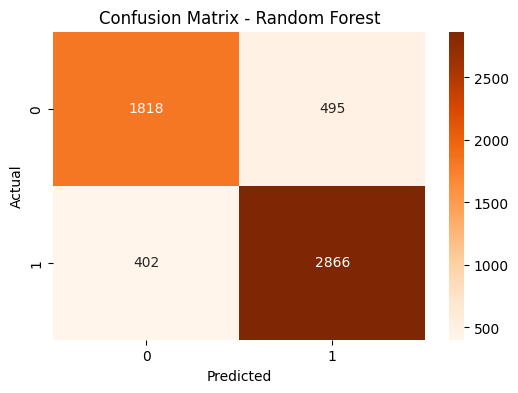

In [ ]:
# Reporte de clasificacion
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Para los estudiantes sin depresión (clase 0), el modelo obtuvo una precisión del 82% y un recall del 79%. Esto indica que la mayoría de los estudiantes clasificados como no depresivos fueron correctamente identificados, aunque algunos casos fueron confundidos con la clase positiva.

Para los estudiantes con depresión (clase 1), el modelo alcanzó una precisión del 85% y un recall del 88%, evidenciando una buena capacidad para identificar correctamente los casos positivos presentes en el conjunto de prueba.

**Verdaderos Negativos (TN)**
El modelo clasificó correctamente 1818 estudiantes que no presentaban depresión.

**Falsos Positivos (FP)**
495 estudiantes fueron clasificados como depresivos cuando realmente no pertenecían a dicha categoría.

**Falsos Negativos (FN)**
402 estudiantes con depresión no fueron identificados correctamente por el modelo.

**Verdaderos Positivos (TP)**
El modelo identificó correctamente 2866 estudiantes que efectivamente presentaban depresión.

# **Conclusion de Random Forest**

El modelo Random Forest obtuvo un desempeño competitivo, alcanzando una exactitud del 83.93% y un F1-Score de 86.47%. La matriz de confusión mostró que el modelo fue capaz de identificar correctamente 2866 estudiantes con depresión.

Aunque los resultados obtenidos son satisfactorios, Random Forest presentó el mayor número de falsos negativos entre los modelos evaluados, lo que implica una menor capacidad para detectar algunos casos de depresión. Debido a la naturaleza del problema estudiado, este aspecto resulta especialmente relevante al comparar su desempeño con el de Regresión Logística y SVM.

# **COMPARACIÓN DE MODELOS**

Con el objetivo de identificar el algoritmo más adecuado para la predicción de depresión estudiantil, se compararon los resultados obtenidos por los tres modelos de clasificación implementados: Regresión Logística, Support Vector Machine (SVM) y Random Forest.

La evaluación se realizó utilizando las métricas Accuracy, Precision, Recall y F1-Score, permitiendo analizar tanto el desempeño general como la capacidad de detección de casos positivos.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.842501,0.855189,0.880049,0.867441
1,SVM,0.842322,0.850352,0.886781,0.868185
2,Random Forest,0.839276,0.852722,0.876989,0.864685


Los resultados muestran que los tres modelos alcanzaron desempeños muy similares, con diferencias inferiores al 1% en todas las métricas evaluadas. Esto indica que las variables seleccionadas poseen una capacidad predictiva consistente independientemente del algoritmo utilizado.

La Regresión Logística obtuvo la mayor exactitud (84.25%) y precisión (85.52%), mientras que SVM alcanzó el mayor recall (88.68%) y el mejor F1-Score (86.82%). Por su parte, Random Forest presentó resultados ligeramente inferiores a los obtenidos por los otros dos modelos.

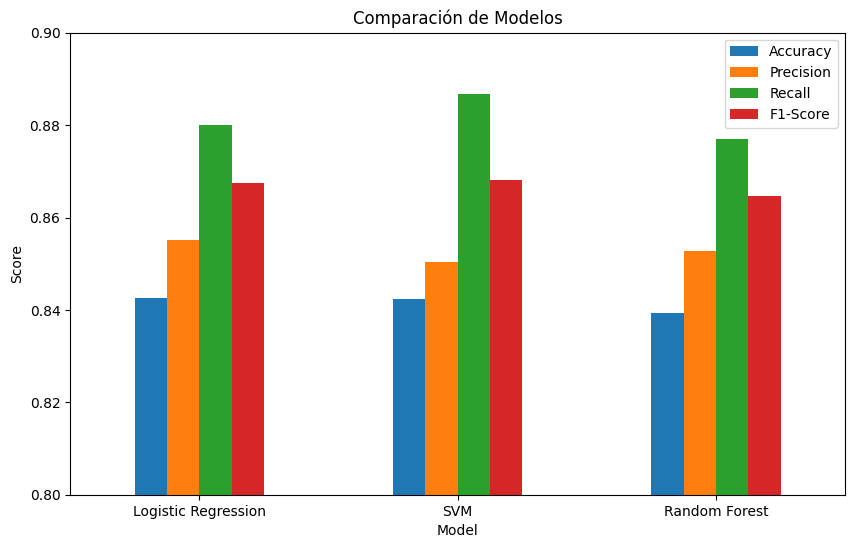

In [ ]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylim(0.80, 0.90)
plt.title("Comparación de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

La Figura muestra una comparación visual del desempeño de los modelos evaluados. Se observa que las barras presentan alturas muy similares para todas las métricas, confirmando que los tres algoritmos ofrecen un comportamiento estable sobre el conjunto de datos.

No obstante, el modelo SVM presenta una ligera ventaja en Recall y F1-Score, métricas especialmente relevantes en problemas de clasificación relacionados con salud mental, donde la detección correcta de casos positivos es prioritaria.

# **Conclusión**

Los tres modelos obtuvieron resultados similares, con valores de Accuracy superiores al 83% y F1-Score superiores al 86%, evidenciando que las variables seleccionadas contienen información relevante para identificar estudiantes con depresión.

El modelo SVM obtuvo los mejores resultados globales al alcanzar el mayor Recall (88.68%), el mayor F1-Score (86.82%) y la menor cantidad de falsos negativos (370 casos). Estos resultados son especialmente importantes debido a que el objetivo principal del proyecto es identificar estudiantes con posibles síntomas de depresión, minimizando la omisión de casos reales.

Por su parte, la Regresión Logística obtuvo la mayor exactitud (84.25%) y precisión (85.52%), demostrando que incluso un modelo lineal es capaz de capturar relaciones significativas dentro del conjunto de datos.

Finalmente, Random Forest presentó un desempeño competitivo, aunque ligeramente inferior al de los otros modelos evaluados.

Considerando el contexto del problema y la importancia de identificar correctamente estudiantes con depresión, se selecciona Support Vector Machine (SVM) como el modelo con mejor desempeño para este conjunto de datos.

# **CROSS VALIDATION**

Hasta este punto, los modelos fueron evaluados utilizando una única partición de entrenamiento y prueba. Sin embargo, los resultados obtenidos pueden depender de la división específica realizada.

Con el fin de evaluar la capacidad de generalización de los modelos y reducir la dependencia de una única partición de entrenamiento y prueba, se aplicó validación cruzada estratificada (divide los datos en bloques iguales) de cinco particiones (Stratified 5-Fold Cross Validation).

Esta metodología garantiza que cada partición conserve la proporción original de las clases de la variable objetivo, permitiendo una evaluación más robusta y confiable del desempeño de los modelos.

**Logistic Regression**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_lr = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1'
)

print("F1 por Fold:")
print(scores_lr)

print("F1 Promedio:")
print(scores_lr.mean())

F1 por Fold:
[0.87384847 0.86951589 0.87013719 0.87272044 0.87052651]
F1 Promedio:
0.8713496988462788


**SVM**

In [ ]:
scores_svm = cross_val_score(
    SVC(kernel='rbf'),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1'
)

print("F1 por Fold:")
print(scores_svm)

print("F1 Promedio:")
print(scores_svm.mean())

F1 por Fold:
[0.87207342 0.86910798 0.87238024 0.86894747 0.86819377]
F1 Promedio:
0.8701405751951639


**Random Forest**

In [ ]:
scores_rf = cross_val_score(
    RandomForestClassifier(random_state=42),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1'
)

print("F1 por Fold:")
print(scores_rf)

print("F1 Promedio:")
print(scores_rf.mean())

F1 por Fold:
[0.86442903 0.86198363 0.86544631 0.86309411 0.86287119]
F1 Promedio:
0.8635648540597893


**Tabla comparativa**

In [ ]:
cv_results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "CV_F1":[
        scores_lr.mean(),
        scores_svm.mean(),
        scores_rf.mean()
    ]
})

cv_results

,Model,CV_F1
0,Logistic Regression,0.871350
1,SVM,0.870141
2,Random Forest,0.863565


# **Conclusión**

Los resultados de validación cruzada confirman que los tres modelos presentan un desempeño estable y consistente. La proximidad entre los resultados obtenidos mediante validación cruzada y los observados sobre el conjunto de prueba demuestra que los modelos son capaces de generalizar adecuadamente a datos no observados previamente.

Asimismo, la Regresión Logística obtuvo el mayor F1-Score promedio durante la validación cruzada, mientras que SVM mantuvo un desempeño muy cercano, confirmando que ambos modelos constituyen alternativas sólidas para la predicción de depresión estudiantil.


Las diferencias observadas entre los resultados de validación cruzada y los obtenidos sobre el conjunto de prueba fueron mínimas, lo que indica una adecuada capacidad de generalización y una baja evidencia de sobreajuste (overfitting).

# **GRIDSEARCHCV**

Los modelos de Machine Learning poseen hiperparámetros que influyen directamente en su desempeño predictivo.

Para identificar las configuraciones más adecuadas se empleó GridSearchCV, técnica que evalúa sistemáticamente múltiples combinaciones de hiperparámetros utilizando validación cruzada.

**Logistic Regression**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_lr = {
    'C':[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled,y_train)

print("Mejores parámetros:")
print(grid_lr.best_params_)

print("Mejor F1:")
print(grid_lr.best_score_)

Mejores parámetros:
{'C': 0.1}
Mejor F1:
0.8714105660624938


**SVM**

In [ ]:
param_svm = {
    'C':[0.1,1,10],
    'gamma':['scale','auto']
}

grid_svm = GridSearchCV(
    SVC(kernel='rbf'),
    param_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled,y_train)

print("Mejores parámetros:")
print(grid_svm.best_params_)

print("Mejor F1:")
print(grid_svm.best_score_)

Mejores parámetros:
{'C': 0.1, 'gamma': 'auto'}
Mejor F1:
0.8718483512616293


**Random Forest**

In [ ]:
param_rf = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled,y_train)

print("Mejores parámetros:")
print(grid_rf.best_params_)

print("Mejor F1:")
print(grid_rf.best_score_)

Mejores parámetros:
{'max_depth': 10, 'n_estimators': 100}
Mejor F1:
0.8700053089938832


**Tabla comparativa**

In [ ]:
grid_results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Best_F1":[
        grid_lr.best_score_,
        grid_svm.best_score_,
        grid_rf.best_score_
    ]
})

grid_results

,Model,Best_F1
0,Logistic Regression,0.871411
1,SVM,0.871848
2,Random Forest,0.870005


# **Conclusión**

**Regresión Logística**
Para la Regresión Logística, el mejor desempeño se obtuvo con un valor de regularización C = 0.1. Este resultado indica que una regularización moderada permite mejorar la capacidad de generalización del modelo, reduciendo el riesgo de sobreajuste sin afectar significativamente su capacidad predictiva. El modelo alcanzó un F1-Score promedio de 0.8714.

**SVM**
Para SVM, la mejor configuración correspondió a un valor de C = 0.1 y gamma = auto.

Esta combinación permitió construir una frontera de decisión con adecuada capacidad de generalización, obteniendo el mejor F1-Score entre todos los modelos evaluados (0.8718).

**Random Forest**
En el caso de Random Forest, la mejor configuración se obtuvo utilizando 100 árboles de decisión y una profundidad máxima de 10 niveles.

Limitar la profundidad de los árboles contribuyó a reducir el riesgo de sobreajuste, permitiendo mejorar ligeramente la capacidad de generalización del modelo.

El mejor F1-Score alcanzado fue de 0.8700, valor competitivo aunque ligeramente inferior al obtenido por Regresión Logística y SVM.

Finalmente, La optimización de hiperparámetros mediante GridSearchCV permitió identificar las configuraciones que maximizan el desempeño de cada modelo.

Los resultados muestran que las diferencias entre los modelos optimizados son mínimas, con F1-Scores superiores al 87% en todos los casos. Esto evidencia que las variables seleccionadas contienen información predictiva consistente y que múltiples enfoques de clasificación son capaces de modelar adecuadamente el problema.

Aunque SVM obtuvo el mejor resultado global, la diferencia respecto a la Regresión Logística fue prácticamente despreciable, sugiriendo que ambos modelos poseen una capacidad predictiva comparable para el conjunto de datos analizado.

# **COMPLEJIDAD COMPUTACIONAL**

El análisis de complejidad computacional permite evaluar el costo de entrenamiento asociado a cada algoritmo de Machine Learning. Este análisis resulta relevante para comprender cómo aumenta el tiempo de procesamiento a medida que crece el volumen de datos y para comparar la eficiencia de los modelos evaluados.

Tomando en cuenta que las complejidades son aproximaciones teóricas generales, tenemos:

In [ ]:
complexity = pd.DataFrame({
    "Modelo":[
        "Logistic Regression",
        "SVM (RBF)",
        "Random Forest"
    ],
    "Complejidad de Entrenamiento":[
        "O(n·p)",
        "O(n²) a O(n³)",
        "O(t·n·log(n))"
    ],
    "Interpretabilidad":[
        "Alta",
        "Media",
        "Media"
    ],
    "Observacion":[
        "Menor costo computacional y alta interpretabilidad",
        "Mayor costo computacional pero excelente capacidad predictiva",
        "Buen equilibrio entre desempeño y complejidad"
    ]
})

complexity

,Modelo,Complejidad de Entrenamiento,Interpretabilidad,Observacion
0,Logistic Regression,O(n·p),Alta,Menor costo computacional y alta interpretabil...
1,SVM (RBF),O(n²) a O(n³),Media,Mayor costo computacional pero excelente capac...
2,Random Forest,O(t·n·log(n)),Media,Buen equilibrio entre desempeño y complejidad


La complejidad presentada corresponde a aproximaciones teóricas ampliamente aceptadas en la literatura para cada algoritmo. En la práctica, el tiempo real de entrenamiento también depende de factores como el tamaño del conjunto de datos, la implementación utilizada y los recursos computacionales disponibles.